In [ ]:
https://api.nasa.gov/

In [ ]:
import requests

# Your provided Client ID (API Key)
CLIENT_ID = 'QpohIdtcV41xj9tj8yhamzkgkpPMvtZ2CMK5Atvs'

# Example Endpoint for Vesta Trek
# Note: You can change 'Vesta' to 'Moon' or 'Mars' in the URL for other bodies
wmts_endpoint = "https://trek.nasa.gov/tiles/Vesta/EQ/Vesta_Dawn_GRaND_ClrIronCorrectedCounts_Global_2ppd/1.0.0"

# Parameters for the specific tile you want
# These values are typically found by parsing the GetCapabilities XML
style = "default"
tile_matrix_set = "default028mm"
zoom_level = "0"
row = "0"
col = "0"

# Construct the full URL with your API Key
url = f"{wmts_endpoint}/{style}/{tile_matrix_set}/{zoom_level}/{row}/{col}.jpg?api_key={CLIENT_ID}"

response = requests.get(url)

if response.status_code == 200:
    with open("trek_tile.jpg", "wb") as f:
        f.write(response.content)
    print("Tile downloaded successfully!")
else:
    print(f"Failed to fetch tile. Status code: {response.status_code}")

Tile downloaded successfully!


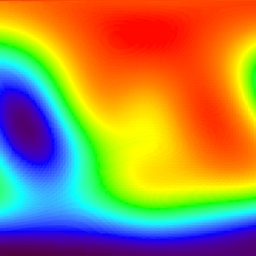

Successfully fetched tile for Vesta


In [ ]:
import requests
from PIL import Image
from io import BytesIO

# 1. Setup Credentials and API endpoint
# Your provided Client ID
CLIENT_ID = 'QpohIdtcV41xj9tj8yhamzkgkpPMvtZ2CMK5Atvs'

# 2. Define parameters for the map tile
# Changed to a known working combination for Vesta
body = 'Vesta'
layer = 'Vesta_Dawn_GRaND_ClrIronCorrectedCounts_Global_2ppd'
zoom_level = '0'
row = '0'
col = '0'

# 3. Construct the API URL
# The WMTS model typically follows this structure: {endpoint}/{layer}/{style}/{tilematrixset}/{zoom}/{row}/{col}.png
base_url = f"https://trek.nasa.gov/tiles/{body}/EQ/{layer}/1.0.0/default/default028mm/{zoom_level}/{row}/{col}.jpg"

# Append the api_key for authentication
final_url = f"{base_url}?api_key={CLIENT_ID}"

# 4. Make the API request
try:
    response = requests.get(final_url)

    # 5. Handle the response
    if response.status_code == 200:
        # Display the map tile
        img = Image.open(BytesIO(response.content))
        # Use display() instead of img.show() for Colab compatibility
        display(img)
        print(f"Successfully fetched tile for {body}")
    else:
        print(f"Failed to fetch data. Status Code: {response.status_code}")
        print(f"Message: {response.text}")

except Exception as e:
    print(f"An error occurred: {e}")

In [ ]:
def latlon_to_tile_coords(lat, lon, zoom):
    """
    Translates standard planetary Latitude and Longitude into
    the corresponding tile Row and Column index numbers.
    Assumes standard global Equirectangular (EQ) projection.
    """
    # Total number of tiles across a row/col axis at this zoom level
    total_tiles = 2 ** zoom

    # 1. Longitude mapping: from [-180, 180] to [0, total_tiles - 1]
    # West is negative (-180), East is positive (+180)
    col = int(((lon + 180.0) / 360.0) * total_tiles)

    # 2. Latitude mapping: from [90, -90] to [0, total_tiles - 1]
    # Note: Tile Row 0 starts from the top North pole and counts downwards to South pole
    row = int(((90.0 - lat) / 180.0) * total_tiles)

    # Ensure coordinates fall safely inside acceptable index boundaries
    col = max(0, min(total_tiles - 1, col))
    row = max(0, min(total_tiles - 1, row))

    return row, col

# --- EXAMPLE USAGE ---
# Target: Olympus Mons on Mars (~ Lat: 18.65, Lon: -134.0) at Zoom Level 3
target_lat = 18.65
target_lon = -134.0
target_zoom = 3

calculated_row, calculated_col = latlon_to_tile_coords(target_lat, target_lon, target_zoom)

print(f" Coordinates Selected: Latitude {target_lat}, Longitude {target_lon}")
print(f" Target Tile Coordinates for Zoom {target_zoom}  Row: {calculated_row}, Column: {calculated_col}")

# Now you can programmatically plug this right into your existing get_trek_tile viewer:
# get_trek_tile(body='Mars', zoom=target_zoom, row=calculated_row, col=calculated_col)

 Coordinates Selected: Latitude 18.65, Longitude -134.0
 Target Tile Coordinates for Zoom 3  Row: 3, Column: 1


## Problem Statement

Planetary scientists, mission planners, and educators require efficient and programmatic access to high-resolution spatial data (e.g., imagery, elevation maps) of celestial bodies like Vesta, Moon, and Mars for research, planning, and public engagement. Manually navigating web interfaces to retrieve specific map tiles can be cumbersome and inefficient for large-scale data analysis or integration into custom applications. There is a need for a streamlined method to retrieve and visualize these planetary map tiles dynamically, facilitating deeper analysis and broader dissemination of scientific data.

### Solution: Dynamic Map Tile Retrieval and Visualization

This interactive tool allows users to dynamically select a celestial body (Vesta, Moon, or Mars), adjust zoom levels, and specify tile coordinates to instantly fetch and display high-resolution map tiles using the NASA Trek WMTS API. This eliminates the need for manual navigation of web interfaces, providing a programmatic and efficient way to access spatial data for research, mission planning, and educational purposes.

In [ ]:
import requests
from IPython.display import Image, display
import ipywidgets as widgets
from IPython.display import display as ipy_display

# Your provided Client ID
CLIENT_ID = 'QpohIdtcV41xj9tj8yhamzkgkpPMvtZ2CMK5Atvs' # Re-using the client ID from previous cells

def get_trek_tile(body, zoom, row, col):
    """
    Fetches a specific map tile from the NASA Trek WMTS API.
    """
    # Define layers for each planetary body
    layers = {
        'Vesta': 'Vesta_Dawn_GRaND_ClrIronCorrectedCounts_Global_2ppd', # Changed to a known working Vesta layer at zoom 0
        'Moon': 'Moon_LRO_WAC_Mosaic_Global_100m_v2',
        'Mars': 'Mars_MRO_CTX_THEMIS_Color'
    }

    layer = layers[body]

    # Base WMTS URL Template
    # Format: {endpoint}/{layer}/{style}/{tilematrixset}/{zoom}/{row}/{col}.png
    base_url = f"https://trek.nasa.gov/tiles/{body}/EQ/{layer}/1.0.0/default/default028mm/{zoom}/{row}/{col}.jpg"

    # Adding the API Key (Client ID)
    url = f"{base_url}?api_key={CLIENT_ID}"

    try:
        response = requests.get(url)
        if response.status_code == 200:
            ipy_display(Image(response.content))
            print(f"Successfully loaded {body} Tile: Zoom {zoom}, Row {row}, Col {col}")
        else:
            print(f"Error {response.status_code}: Could not fetch tile. Ensure coordinates are valid for this zoom level. Requested URL: {url}")
    except Exception as e:
        print(f"Request failed: {e}")

# Create Interactive Controls with dynamic ranges for row and col
body_widget = widgets.Dropdown(options=['Vesta', 'Moon', 'Mars'], value='Vesta', description='Body:')
zoom_widget = widgets.IntSlider(min=0, max=5, step=1, value=0, description='Zoom:')
row_widget = widgets.IntSlider(min=0, max=0, step=1, value=0, description='Row:') # Initial max will be set by observer
col_widget = widgets.IntSlider(min=0, max=0, step=1, value=0, description='Col:') # Initial max will be set by observer

def update_row_col_max(*args):
    max_val = (2**zoom_widget.value) - 1
    row_widget.max = max_val
    col_widget.max = max_val
    # Reset value to prevent being out of bounds if new max is smaller
    if row_widget.value > max_val: row_widget.value = max_val
    if col_widget.value > max_val: col_widget.value = max_val

zoom_widget.observe(update_row_col_max, 'value')

# Call it once to set initial max values based on initial zoom_widget.value
update_row_col_max()

# Link widgets to the function
interactive_output = widgets.interactive_output(get_trek_tile, {
    'body': body_widget,
    'zoom': zoom_widget,
    'row': row_widget,
    'col': col_widget
})

# Display the widgets and the output
ipy_display(body_widget, zoom_widget, row_widget, col_widget, interactive_output)

Dropdown(description='Body:', options=('Vesta', 'Moon', 'Mars'), value='Vesta')

IntSlider(value=0, description='Zoom:', max=5)

IntSlider(value=0, description='Row:', max=0)

IntSlider(value=0, description='Col:', max=0)

Output()